In [1]:
#importing needed libraries
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

import osmnx as ox

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

import plotly.express as px
import plotly.graph_objects as go

## Step 1: Getting the Data and Exploratory Data Analysis

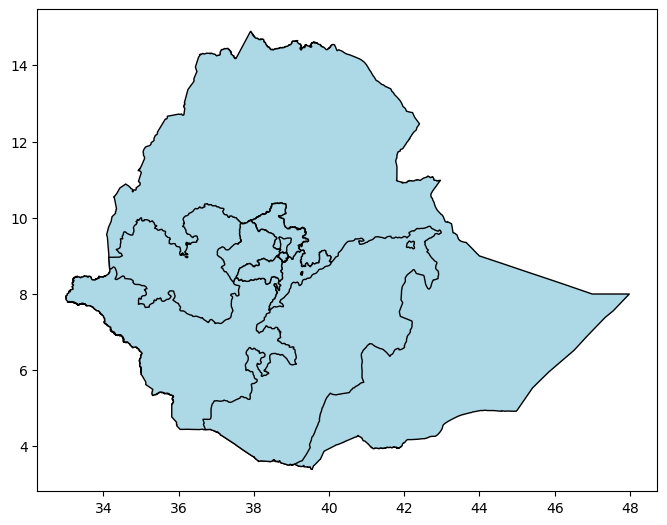

In [3]:
# Define location and tags
place = "አዲስ አበባ Addis Ababa أديس أبابا, ኢትዮጵያ إثيوبيا"
tags = {"boundary": "administrative", "admin_level": "30"}

# Load subcities as polygons
gdf = ox.features_from_place(place, tags)
gdf = gdf[gdf.geometry.type.isin(["Polygon", "MultiPolygon"])]
gdf.plot(figsize=(8, 8), edgecolor="black", color="lightblue")
plt.show()

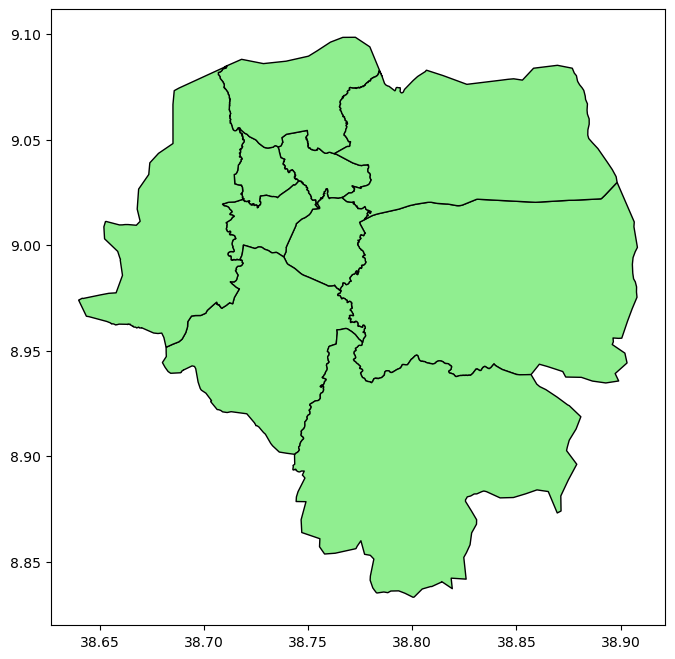

In [4]:
#filtering only sub cities of Addis Ababa (no Lemi Kura in openstreetmap's data)
gdf_filtered = gdf.loc[gdf["name"].isin([
    'Arada', 'Bole', 'Addis Ketema',
    'Kirkos', 'Gulale', 'Lideta', 'Yeka',
    'Nefas Silk', 'Akaki Kaliti', 'Kolfe Keranio'
]), ["name", "geometry"]].reset_index(drop=True)

# Plot with color and figsize
gdf_filtered.plot(edgecolor="black", color="lightgreen", figsize=(8, 8));
plt.show()

In [5]:
#getting shop features
place = "Addis Ababa, Ethiopia"
tags = {"shop": True}
poi = ox.features_from_place("Addis Ababa, Ethiopia", tags)

#getting building features
tags = {"building" : True}
buildings = ox.features_from_place(place, tags)
buildings = buildings[buildings.geometry.type.isin(["Polygon", "MultiPolygon"])]

#getting road networks
G = ox.graph_from_place(place, network_type="drive")
edges = ox.graph_to_gdfs(G, nodes=False)

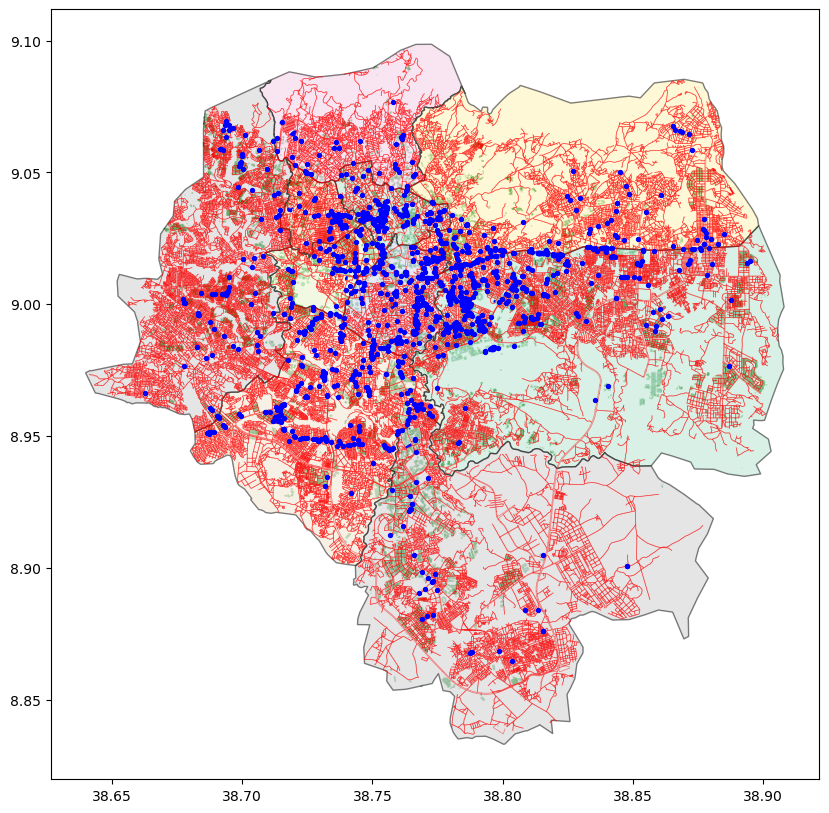

In [6]:
#plotting shop, buildings, and roads to see which features come close to showing population density
fig, ax = plt.subplots(1, 1, figsize=(10, 10))

edges.plot(ax=ax, edgecolor="red", linewidth=0.5, alpha=0.5)
buildings.plot(ax=ax, edgecolor="green", alpha=0.3)
gdf_filtered.plot(ax=ax, edgecolor="black", cmap="Pastel2", alpha=0.5)
poi.plot(ax=ax, markersize=8, color="blue", zorder=3)

plt.show()

## Step 2: Prepare Data for Clustering 

In [7]:
#taking the roads line column only
edges = edges[["geometry"]].reset_index(drop=True)
edges.head()

,geometry
0,"LINESTRING (38.79066 9.01506, 38.79124 9.01521)"
1,"LINESTRING (38.79066 9.01506, 38.79085 9.01426)"
2,"LINESTRING (38.79066 9.01506, 38.79049 9.01587)"
3,"LINESTRING (38.79258 9.01555, 38.79171 9.01533)"
4,"LINESTRING (38.79258 9.01555, 38.79265 9.01535..."


In [8]:
#checking the crs
edges.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [9]:
edge_points = edges.copy()
#converting to meters crs (UTM zone 37N for Ethiopia)
edge_points = edge_points.to_crs("EPSG:32637")
edge_points.crs

<Projected CRS: EPSG:32637>
Name: WGS 84 / UTM zone 37N
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 36°E and 42°E, northern hemisphere between equator and 84°N, onshore and offshore. Djibouti. Egypt. Eritrea. Ethiopia. Georgia. Iraq. Jordan. Kenya. Lebanon. Russian Federation. Saudi Arabia. Somalia. Sudan. Syria. Türkiye (Turkey). Ukraine.
- bounds: (36.0, 0.0, 42.0, 84.0)
Coordinate Operation:
- name: UTM zone 37N
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [10]:
# calculating the mid point of the road
# .centroid can pick a point outside the road for curved roads
# normalized=True means 0.5 refers to 50% of the line's length not absolute distance
edge_points["geometry"] = edge_points.geometry.interpolate(0.5, normalized=True)
edge_points["x"] = edge_points.geometry.x
edge_points["y"] = edge_points.geometry.y
edge_points.head()

,geometry,x,y
0,POINT (477023.394 996532.14),477023.393590,996532.140074
1,POINT (477002.233 996479.67),477002.233358,996479.670263
2,POINT (476982.138 996568.742),476982.137815,996568.741801
3,POINT (477154.629 996565.692),477154.628883,996565.691500
4,POINT (477209.035 996559.436),477209.034800,996559.436041


In [11]:
# convering to numpy array and scaling
X = edge_points[["x", "y"]].values
scaler = StandardScaler()
X = scaler.fit_transform(X)

## Step 3: Run KMeans Clustering 

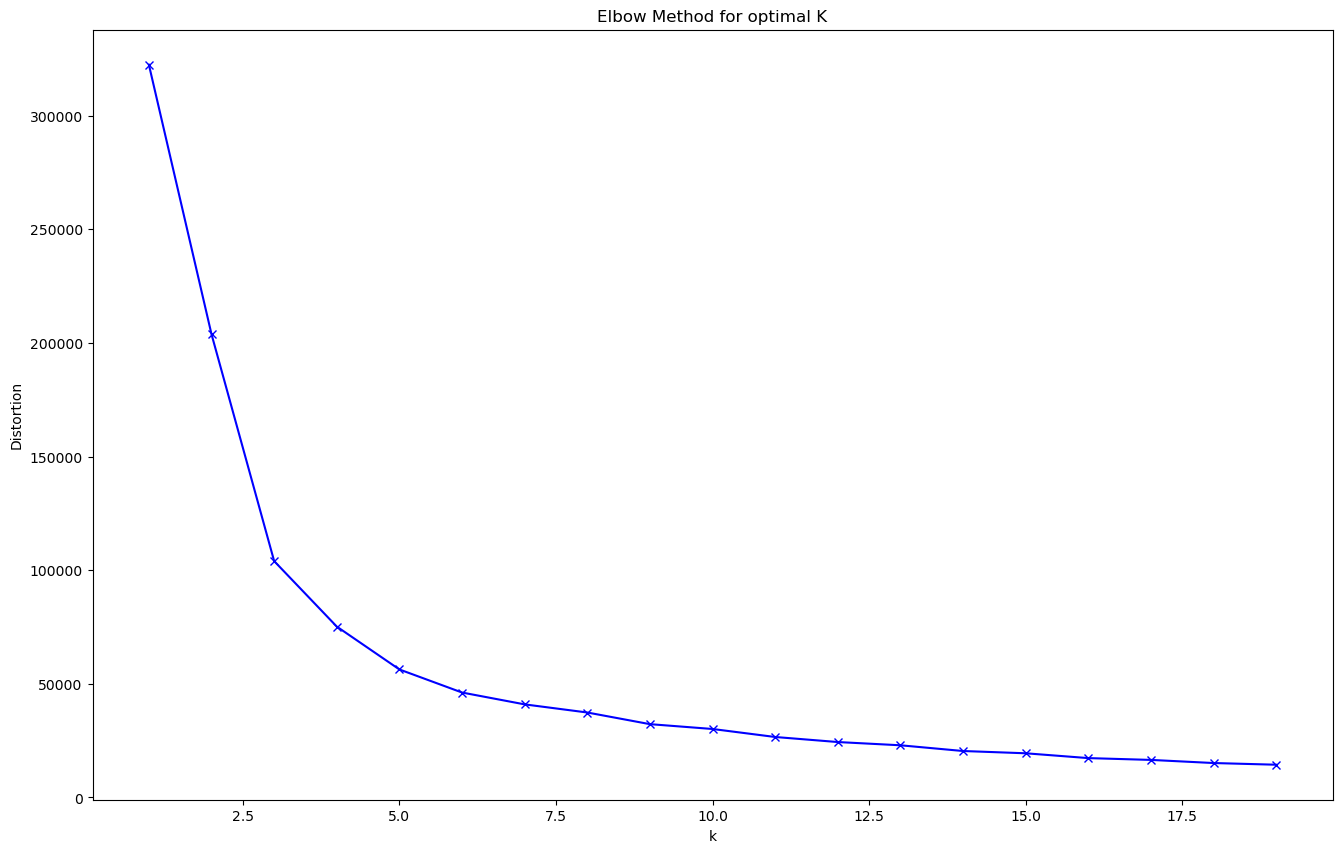

In [12]:
# plotting an elbow plot
distortions = []
K = range(1, 20)
for k in K:
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X)
    distortions.append(kmeans.inertia_)
plt.figure(figsize=(16, 10))
plt.plot(K, distortions, "bx-")
plt.title("Elbow Method for optimal K")
plt.xlabel("k")
plt.ylabel("Distortion")
plt.show()

In [13]:
# building and fitting KMeans clustering
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_7 = kmeans.fit(X)
kmeans_7.labels_

array([1, 1, 1, ..., 1, 1, 1], shape=(161196,), dtype=int32)

In [14]:
# creating a column with the clusters
edge_points["cluster"] = kmeans_7.labels_
edge_points = edge_points.set_geometry("geometry")

In [15]:
# converting to degrees
edge_points_latlon = edge_points.to_crs("EPSG:4326")

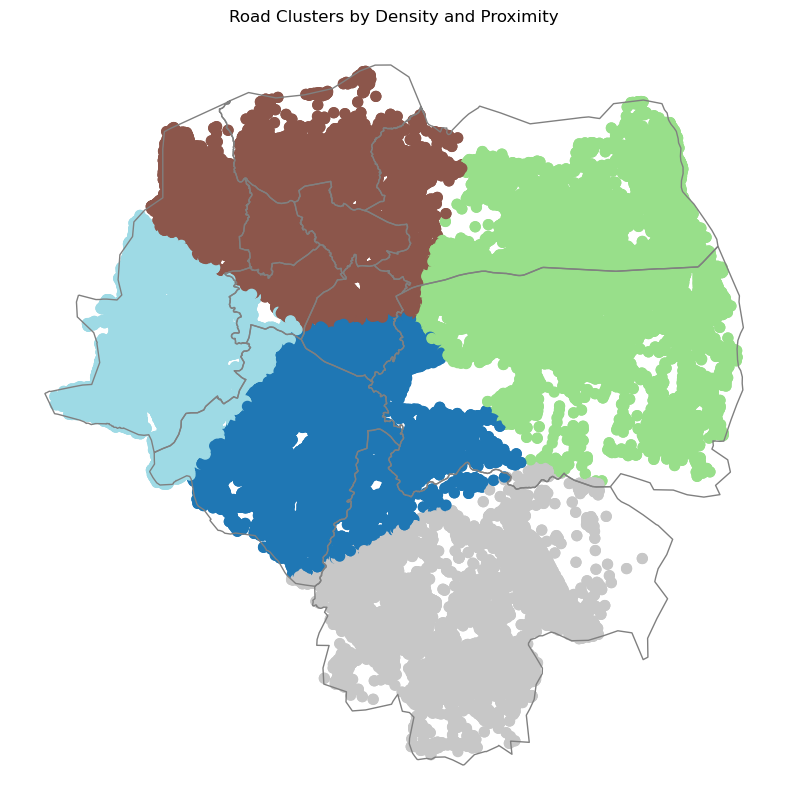

In [16]:
#Kmeans plot
fig, ax = plt.subplots(figsize=(10, 10))
edge_points_latlon.plot(column="cluster", ax=ax, cmap="tab20", markersize=50)
gdf_filtered.plot(edgecolor="grey", ax=ax, facecolor="none", linewidth=1)
plt.title("Road Clusters by Density and Proximity")
ax.set_axis_off()
plt.show()

In [17]:
#Extracting cluster centroids
cluster_centers = scaler.inverse_transform(kmeans.cluster_centers_)
cluster_centers_gdf = gpd.GeoDataFrame(geometry=gpd.points_from_xy(cluster_centers[:, 0], cluster_centers[:, 1]), crs="EPSG:32637")
cluster_centers_gdf = cluster_centers_gdf.to_crs("EPSG:4326")
cluster_coords = cluster_centers_gdf.geometry.apply(lambda pt: (pt.y, pt.x))

cluster_coords

0    (8.957016731872693, 38.74966917014733)
1     (9.013933940654736, 38.8423256569419)
2    (9.042247109662005, 38.73670879834218)
3    (8.885423773054322, 38.79439284544914)
4    (8.990493293032067, 38.68935145079246)
Name: geometry, dtype: object

## Step 4: Evaluating the Model

In [18]:
#evaluating the model
score = silhouette_score(X, edge_points["cluster"])
print(f"Silhouette Score: {score:.2f}")

Silhouette Score: 0.45


## Step 5: Creating an Interactive Plot

In [ ]:
# Convert clusters to DataFrame
cluster_df = pd.DataFrame({
    'lat': edge_points_latlon.geometry.y,
    'lon': edge_points_latlon.geometry.x,
    'cluster': edge_points_latlon['cluster'] + 1  # Clusters start from 1
})

# Create base scatter map
fig = px.scatter_map(
    cluster_df,
    lat="lat",
    lon="lon",
    color="cluster",
    color_discrete_sequence=px.colors.qualitative.Plotly,
    zoom=11,
    height=800,
    title="Addis Ababa Road Clusters",
    opacity=0.3,
    hover_data=['cluster'],
    map_style="open-street-map"
)

# Add cluster centers with prominent markers
centroid_df = pd.DataFrame({
    'lat': [pt.y for pt in cluster_centers_gdf.geometry],
    'lon': [pt.x for pt in cluster_centers_gdf.geometry],
    'cluster': [f"Cluster Center {i+1}" for i in range(len(cluster_centers_gdf))]
})


fig.add_trace(go.Scattermap(
    lat=centroid_df['lat'],
    lon=centroid_df['lon'],
    mode='markers+text',
    marker=dict(
        size=24,  # Larger size
        color='darkorange',  # Vibrant color
        symbol='triangle-up',  # Distinct shape
        opacity=1
    ),
    text=centroid_df['cluster'],
    textposition="top center",
    textfont=dict(
        size=30,
        color='white'
    ),
    hoverinfo='text',
    name='Cluster Centers'
))

# Configure map view
fig.update_layout(
    mapbox=dict(
        center=dict(lat=9.03, lon=38.74),
        zoom=11,
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    )
)

# Style regular points
fig.update_traces(
    marker=dict(
        size=4,
        opacity=0.3
    ),
    selector=dict(mode='markers')
)

fig.write_html("output/map.html")